In [2]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn.objects as so
import seaborn as sns
from matplotlib import rcParams

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.load import load_multisensory_data

In [3]:
df = load_multisensory_data(base_path="../data")
df.columns


Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)


Index(['participant', 'perturb', 'session', 'phase', 'trial_number', 'type',
       'vis_noise', 'cursor_offset', 'time', 'lefty_pos', 'leftx_pos',
       'righty_pos', 'rightx_pos', 'cursory_pos'],
      dtype='object')

In [4]:
df["tracking_error"] = df["righty_pos"] - df["lefty_pos"]
df["tracking_mse"] = df["tracking_error"] ** 2

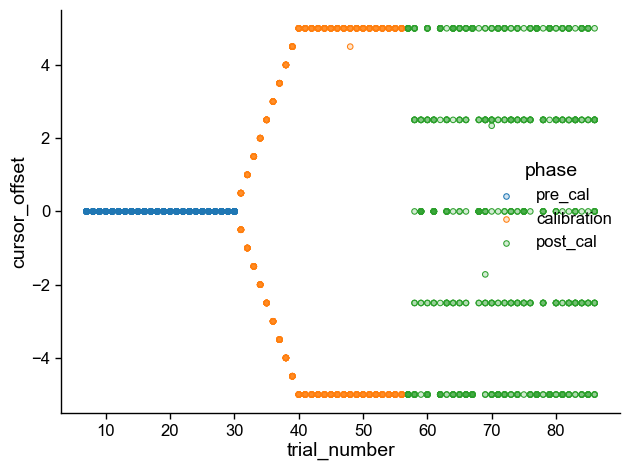

In [5]:
g = so.Plot(
    df, x="trial_number", y="cursor_offset", color="phase", group="participant"
).add(so.Dots(), so.Agg())
g.show()

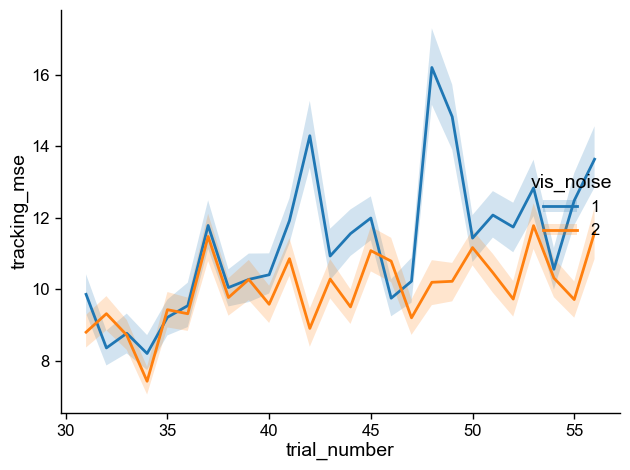

In [6]:
g = (
    so.Plot(
        df[df["phase"] == "calibration"],
        x="trial_number",
        y="tracking_mse",
        color="vis_noise",
    )
    .add(so.Line(), so.Agg())
    .add(so.Band(), so.Est())
    .scale(color=so.Nominal())
    # .facet(col="perturb")
)
g.show()

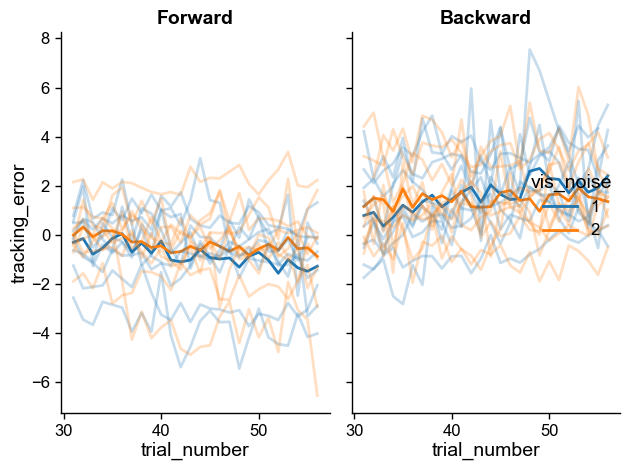

In [19]:
g = (
    so.Plot(
        df[df["phase"] == "calibration"],
        x="trial_number",
        y="tracking_error",
        color="vis_noise",
    )
    .add(so.Line(), so.Agg())
    .add(so.Line(alpha=0.25), so.Agg(), group="participant")
    .scale(color=so.Nominal())
    .facet(col="perturb")
)
g.show()

## Simulate offset model

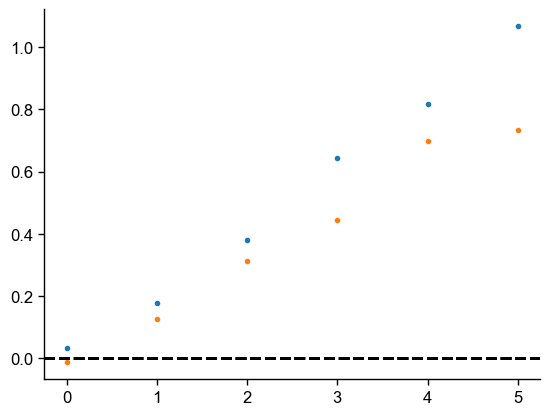

In [17]:
from jax import random
import jax.numpy as jnp

from cppp.models.multisensory import SubjectiveBiasMultisensoryDelayModel

dt = 1 / 18.18

random_walk_std = 1.2
action_variability = 0.3
action_cost = 0.02
sigma_prop = 7.
sigma_vis = {"lo": 12., "hi": 15.}

key = random.PRNGKey(0)
for name, sigma in sigma_vis.items():
    for bias in [0, 1, 2, 3, 4, 5]:

        model = SubjectiveBiasMultisensoryDelayModel(
                process_noise=random_walk_std,
                sigmas=[sigma_prop, sigma],
                action_variability=action_variability,
                action_cost=action_cost,
                dt=dt,
                delays=[1, 2],
                T=1000,
            )
        
        key, subkey = random.split(key)
        x = model.simulate(
            rng_key=subkey, n=100, x0=jnp.array([0.0, 0.0, bias] + [0.0] * 6),
        )
        error = jnp.mean((x[..., 1] - x[..., 0]))

        plt.scatter(bias, error, color="C0" if name == "lo" else "C1")
        plt.axhline(0, color="black", linestyle="--")